# Critical stimulus

In [1]:
import immunowave as iw
import diffrax as dx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import math

jax.config.update("jax_enable_x64", True)

### Define model

Our state is only $u(\mathbf{x},t)$

In [2]:
class State(iw.State):
    u: iw.ScalarField

Our dynamical variable $u$ satisfies
$$
\partial_t u = \nabla^2 u + f(u) + 2 I \delta
$$

where
$$
f(u) = \frac{u^n}{K^n + u^n} - u
$$
with $I, K > 0$, and $n > 1$.

In [ ]:
class Model(iw.Model):
    K: float
    n: float
    I: float
    # Bandwidth adjustment for Dirac delta approximation (grid units)
    bw_adjust: float = 2.0

    def f(self, u):
        K, n = self.K, self.n
        return u.hill(K, n) - u

    def delta(self, u):
        """Helper function to approximate a Dirac delta as a Gaussian on the same grid as u."""
        σ = self.bw_adjust * u.h

        def gaussian(*coords):
            squared_dist = sum(coord**2 for coord in coords)
            return jnp.exp(-squared_dist / (2 * σ**2))

        result = iw.ScalarField(u.values.shape, u.lb, u.h, fn=gaussian)
        result /= result.integral()
        return result

    def __call__(self, t, state: State, args=None):
        u = state.u
        Δu = u.laplacian(bc="neumann")
        f = self.f
        I = self.I
        δ = self.delta(u)

        dudt = Δu + f(u) + 2 * I * δ

        return State(dudt)

### Analytical $I_c$

For $K\ll1$, the unstable fixed point is approximately $u_1 \approx K^{n/(n-1)}$, and the critical stimulus is
$$
I_c \approx \sqrt{\frac{n-1}{n+1}}\,u_1
$$


In [4]:
def u1(K, n):
    return K ** (n / (n - 1))


def Ic(K, n):
    return ((n - 1) / (n + 1)) ** 0.5 * u1(K, n)

Set reference parameters

In [5]:
K = 0.01
n = 2.0

In [6]:
u1(K, n), Ic(K, n)

(0.0001, 5.773502691896258e-05)

Plot the Hill function $f(u)$ and the line $u$.

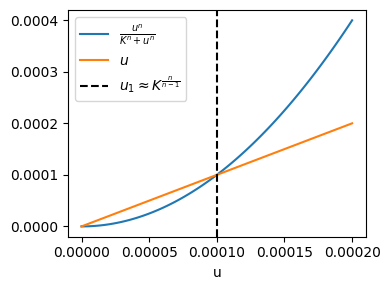

In [7]:
u_grid = jnp.linspace(0, 2 * u1(K, n), 100)

plt.figure(figsize=(4, 3))
plt.plot(u_grid, u_grid**n / (K**n + u_grid**n), label=r"$\frac{u^n}{K^n + u^n}$")
plt.plot(u_grid, u_grid, label=r"$u$")
plt.axvline(u1(K, n), color="k", linestyle="--", label=r"$u_1\approx K^\frac{n}{n-1}$")
plt.xlabel("u")
plt.legend()
plt.tight_layout()
plt.show()

### Initialize fields

Spatial discretization, initialized to zero.

In [9]:
L = 20.0
lb = [-L / 2]
n_spatial = 200
shape = (n_spatial,)
h = L / (n_spatial - 1)

state = State(u=iw.ScalarField(shape, lb, h, 0))

## Solve

Define the integration region as $t\ge 0$, and solve until steady state, taking only the final time only.
We will define a custom norm to identify the steady state via the spatial region within distance $L/4$ from the origin (avoiding boundary effects).

In [10]:
t0 = 0.0
t1 = jnp.inf


@jax.jit
def norm(state: State):
    d = state.u.ndim
    L = state.u.ub[0] - state.u.lb[0]  # Length of the domain in first dimension
    # indicator function for middle of the domain
    ind = iw.ScalarField(
        state.u.values.shape,
        state.u.lb,
        state.u.h,
        fn=lambda *coords: jnp.where(
            sum(abs(coord) ** d for coord in coords) ** (1 / d) < L / 4, 1.0, 0.0
        ),
    )
    return (ind * state.u).integral() / ind.integral()


steady_state_event = dx.Event(dx.steady_state_event(atol=0, rtol=1e-3, norm=norm))

Keyword arguments for the solver

In [11]:
kwargs = dict(
    dt0=1e-4,
    max_steps=10000000,
    atol=1e-8,
    rtol=1e-8,
    throw=True,
    event=steady_state_event,
)

### Mean activation at steady state

In [12]:
@jax.jit
def mean_activation(model, state):
    steady_state = iw.solve(model, state, 0, jnp.inf, **kwargs).ys.u.map(jnp.squeeze)
    area = math.prod(ub - lb for ub, lb in zip(state.u.ub, state.u.lb))
    return steady_state.integral() / area

Solve over a grid of $I$ values, and plot the mean activation at steady state.

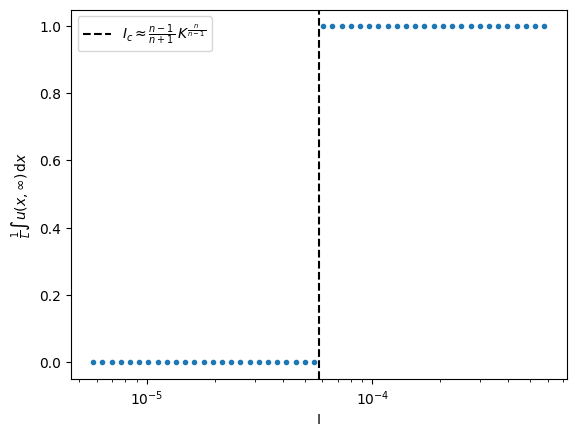

In [13]:
I_grid = jnp.geomspace(0.1 * Ic(K, n), 10 * Ic(K, n), 50)
models = [Model(K=K, n=n, I=I) for I in I_grid]

plt.plot(I_grid, [mean_activation(model, state) for model in models], ".")
plt.axvline(
    Ic(K, n),
    color="k",
    linestyle="--",
    label=r"$I_c \approx \frac{n-1}{n+1}\,K^\frac{n}{n-1}$",
)
plt.legend()
plt.xlabel("I")
plt.ylabel(r"$\frac{1}{L} \int u(x, \infty) \, \mathrm{d}x$")
plt.xscale("log")
plt.show()

### Bisection algorithm for $I_c$

Define a function to perform a bisection algorithm to find the critical stimulus $I_c$.
The idea is to bound from below and above the critical stimulus, and then solve the steady state for the midpoint of the bounding interval.
If the midpoint results in an activated steady state, the midpoint becomes the new upper bound, otherwise it becomes the new lower bound.
The bounding interval is thus reduced by half at each iteration.

In [ ]:
def find_Ic(model, state, tolerance=1e-3, max_iterations=20, verbose=False):
    _print = print if verbose else lambda *args, **kwargs: None
    # initial bounds
    model_low = eqx.tree_at(lambda m: m.I, model, 0.9 * model.I)
    model_high = eqx.tree_at(lambda m: m.I, model, 1.1 * model.I)
    # If low bound doesn't give low activation, reduce it
    while mean_activation(model_low, state) > 0.5:
        _print("decreasing invalid lower bound")
        model_low = eqx.tree_at(lambda m: m.I, model_low, model_low.I / 2)
    # If high bound doesn't give high activation, increase it
    while mean_activation(model_high, state) < 0.5:
        _print("increasing invalid upper bound")
        model_high = eqx.tree_at(lambda m: m.I, model_high, 2 * model_high.I)

    # Iteratively bisect bounding interval
    for i in range(max_iterations):
        _print(f"iter {i}: [{model_low.I:.3e}, {model_high.I:.3e}]")
        model_mid = eqx.tree_at(
            lambda m: m.I, model_low, (model_low.I + model_high.I) / 2
        )
        if (model_high.I - model_low.I) / model_mid.I < tolerance:
            _print(f"tolerance satisifed: Ic = {model_mid.I:.3e}")
            return model_mid
        if mean_activation(model_mid, state) < 0.5:
            model_low = eqx.tree_at(lambda m: m.I, model, model_mid.I)
        else:
            model_high = eqx.tree_at(lambda m: m.I, model, model_mid.I)

    raise RuntimeError("max iterations reached")
    return model_mid

Find the critical stimulus $I_c$ numerically for the reference model, and compare with the theoretical value.

In [15]:
model = Model(K=K, n=n, I=Ic(K, n))
model

Model(K=0.01, n=2.0, I=5.773502691896258e-05)

In [16]:
find_Ic(model, state, verbose=True)
print(f"\ntheoretical Ic = {Ic(K, n):.3e}")

iter 0: [5.196e-05, 6.351e-05]
iter 1: [5.774e-05, 6.351e-05]
iter 2: [5.774e-05, 6.062e-05]
iter 3: [5.774e-05, 5.918e-05]
iter 4: [5.846e-05, 5.918e-05]
iter 5: [5.846e-05, 5.882e-05]
iter 6: [5.864e-05, 5.882e-05]
iter 7: [5.873e-05, 5.882e-05]
iter 8: [5.877e-05, 5.882e-05]
tolerance satisifed: Ic = 5.880e-05

theoretical Ic = 5.774e-05


Find the critical stimulus $I_c$ numerically over a grid of $K$, and compare with the theoretical values.

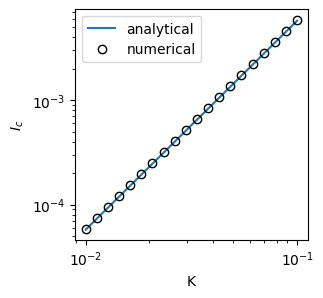

Array([1.01835938, 1.01835938, 1.01835937, 1.01835937, 1.01835937,
       1.01835937, 1.01835938, 1.01835937, 1.01835938, 1.01835938,
       1.01835938, 1.01914063, 1.01914063, 1.01914063, 1.01992187,
       1.01992187, 1.02070313, 1.02148438, 1.02226562, 1.02382813],      dtype=float64)

In [17]:
def K_sweep(state):
    K_grid = jnp.geomspace(0.01, 0.1, 20)
    models = [Model(K=K, n=n, I=Ic(K, n)) for K in K_grid]
    Ic_grid = jnp.array([find_Ic(model, state).I for model in models])

    plt.figure(figsize=(3, 3))
    plt.plot(K_grid, Ic(K_grid, n), "-", label="analytical")
    plt.plot(K_grid, Ic_grid, "ko", label="numerical", fillstyle="none")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("K")
    plt.ylabel(r"$I_c$")
    plt.legend()
    plt.show()

    display(Ic_grid / Ic(K_grid, n))


K_sweep(state)

Similarly, over a grid of $n$.

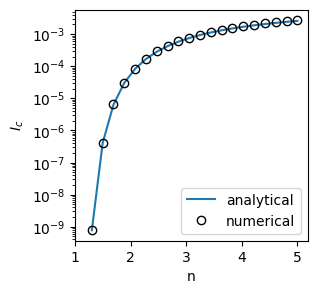

Array([1.00898438, 1.01132812, 1.01367188, 1.01601563, 1.01914063,
       1.02148438, 1.02382813, 1.02695313, 1.02929688, 1.03085938,
       1.03320312, 1.03554688, 1.03710938, 1.03945313, 1.04101562,
       1.04257812, 1.04414063, 1.04648438, 1.04804688, 1.04960937],      dtype=float64)

In [18]:
def n_sweep(state):
    n_grid = jnp.linspace(1.3, 5.0, 20)
    models = [Model(K=K, n=n, I=Ic(K, n)) for n in n_grid]
    Ic_grid = jnp.array([find_Ic(model, state).I for model in models])

    plt.figure(figsize=(3, 3))
    plt.plot(n_grid, Ic(K, n_grid), "-", label="analytical")
    plt.plot(n_grid, Ic_grid, "ko", label="numerical", fillstyle="none")
    plt.yscale("log")
    plt.xlabel("n")
    plt.ylabel(r"$I_c$")
    plt.xlim(1, None)
    plt.legend()
    plt.show()

    display(Ic_grid / Ic(K, n_grid))


n_sweep(state)

## 2D

Now we can reap the rewards of code abstraction, and rerun the above with a 2D spatial domain.

In [ ]:
L = 20.0
lb = [-L / 2, -L / 2]
n_spatial = 40
shape = (n_spatial, n_spatial)
h = L / (n_spatial - 1)

state = State(u=iw.ScalarField(shape, lb, h, 0))

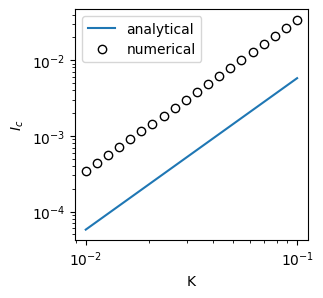

Array([5.87800293, 5.87800293, 5.88186035, 5.88186035, 5.88186035,
       5.88186035, 5.88186035, 5.88186035, 5.88186035, 5.88571777,
       5.88571777, 5.88571777, 5.8895752 , 5.89343262, 5.89343262,
       5.90114746, 5.90500488, 5.91271973, 5.92043457, 5.93200684],      dtype=float64)

In [23]:
K_sweep(state)

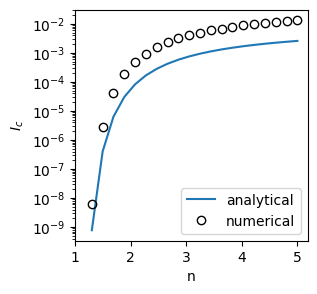

Array([8.20209961, 6.95808105, 6.36403809, 6.02072754, 5.80085449,
       5.65041504, 5.5385498 , 5.45754395, 5.3958252 , 5.34567871,
       5.30710449, 5.27624512, 5.24924316, 5.22995605, 5.21452637,
       5.19909668, 5.18752441, 5.17595215, 5.1682373 , 5.16052246],      dtype=float64)

In [24]:
n_sweep(state)